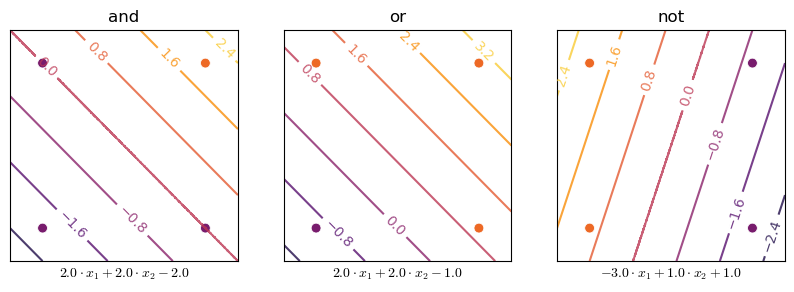

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import Perceptron


def grid(func, *args):  # 计算格点上的函数值 用于后续画等高线或热力图
    x_min, x_max, y_min, y_max = args
    grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))
    grid_z = func(np.column_stack((grid_x.ravel(), grid_y.ravel())))
    grid_z = grid_z.reshape(grid_x.shape)
    return grid_x, grid_y, grid_z


X = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
y_and = np.array([1, 0, 0, 0])
y_or = np.array([1, 1, 1, 0])
y_not = np.array([0, 0, 1, 1])
tasks = [(X, y_and, 'and'), (X, y_or, 'or'), (X, y_not, 'not')]
x_min, x_max, y_min, y_max = -0.2, 1.2, -0.2, 1.2

plt.rcParams.update({
    "mathtext.fontset": 'cm',
    "axes.unicode_minus": True,
})

fig, ax = plt.subplots(1, 3, figsize=(10, 3))

for i, (X, y, name) in enumerate(tasks):

    clf = Perceptron(tol=1e-3, random_state=0)
    clf.fit(X, y)  # 训练模型
    score = clf.score(X, y)  # 训练精度

    ax[i].set(xlim=(x_min, x_max), ylim=(y_min, y_max), xticks=(), yticks=(), title=f"{name}")
    if clf.intercept_[0] < 0:
        ax[i].set_xlabel(rf"${clf.coef_[0, 0]} \cdot x_1 + {clf.coef_[0, 1]} \cdot x_2 {clf.intercept_[0]}$")
    else:
        ax[i].set_xlabel(rf"${clf.coef_[0, 0]} \cdot x_1 + {clf.coef_[0, 1]} \cdot x_2 + {clf.intercept_[0]}$")

    grid_x, grid_y, grid_z = grid(clf.decision_function, x_min, x_max, y_min, y_max)

    contours = ax[i].contour(grid_x, grid_y, grid_z, 6, cmap="inferno", alpha=.8)
    ax[i].clabel(contours, inline=True)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], s=50, hue=y, palette="inferno", legend=False, ax=ax[i])

plt.show()